# Import Libraries
Import necessary libraries including pandas, numpy, matplotlib, seaborn, cmdstanpy, and arviz to support data manipulation, statistical modeling, and visualization.

In [4]:
# Import Libraries
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import cmdstanpy
from cmdstanpy import CmdStanModel
import arviz as az

# Set plotting style for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(font_scale=1.2, rc={'axes.titlesize': plt.rcParams['font.size'] * 1.5})
np.random.seed(42)  # For reproducibility

In [5]:
import matplotlib as mpl

# Set all text elements to pure black
mpl.rcParams['text.color'] = 'black'
mpl.rcParams['axes.labelcolor'] = 'black'
mpl.rcParams['xtick.color'] = 'black'
mpl.rcParams['ytick.color'] = 'black'
mpl.rcParams['axes.titlecolor'] = 'black'

mpl.rcParams['text.color'] = '.03'
mpl.rcParams['axes.labelcolor'] = '.03'
mpl.rcParams['xtick.color'] = '.03'
mpl.rcParams['ytick.color'] = '.03'
mpl.rcParams['axes.titlecolor'] = '.03'

# Load and Preprocess Data
Load the normalized yearly data and prepare it for modeling. Handle the unique county identification by using both county and voivodeship fields. Process the yearly data similarly to the weekly data but focusing on county-level observations instead of weekly countrywide statistics.

In [6]:
# Load and Preprocess Data

# Define project paths
PROJECT_ROOT = Path(os.getenv("PROJECT_ROOT", "."))
DATA_DIR = PROJECT_ROOT / "data"
OUTPUT_DIR = PROJECT_ROOT / "data" / "analysis"

# Load normalized yearly data
print("Loading normalized yearly data...")
df_yearly = pd.read_csv(OUTPUT_DIR / 'normalized_yearly_data.csv')

# Ensure unique identification of counties using both county and voivodeship
df_yearly['county_id'] = df_yearly['county'] + '_' + df_yearly['voivodeship']

# Display the first few rows of the dataframe
print("First few rows of the dataframe:")
print(df_yearly.head())

# Check for missing values
missing_values = df_yearly.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Fill missing values if any
if missing_values.sum() > 0:
    print("Filling missing values with appropriate methods...")
    df_yearly = df_yearly.fillna(method='ffill')

# Check data after filling
print("Remaining missing values:\n", df_yearly.isnull().sum())

# Ensure appropriate data types
df_yearly['year'] = pd.to_numeric(df_yearly['year'])
df_yearly['county'] = df_yearly['county'].astype(str)
df_yearly['voivodeship'] = df_yearly['voivodeship'].astype(str)

# Display the prepared data dimensions
print(f"Data dimensions: {df_yearly.shape}")

# Display the first few rows of the cleaned dataframe
print("First few rows of the cleaned dataframe:")
print(df_yearly.head())

Loading normalized yearly data...
First few rows of the dataframe:
           county voivodeship  year  mean_temperature  mean_humidity  \
0  Biała Podlaska   lubelskie  2020          0.450783       0.050251   
1  Biała Podlaska   lubelskie  2021         -1.587137       1.272068   
2  Biała Podlaska   lubelskie  2022         -0.505457      -0.089261   
3  Biała Podlaska   lubelskie  2023          0.594655      -0.176783   
4       Białystok   podlaskie  2020          0.081436       0.448347   

   total_precipitation  population_density  paved_roads  improved_roads  \
0            -0.220034            7.025627     4.722953        4.720283   
1            -0.676595            7.017865     4.736198        4.734443   
2            -0.359752            7.011845     4.742320        4.739701   
3            -0.566699            7.006061     4.748404        4.745801   
4            -0.203995            7.967731     5.610204        5.605802   

   total_vehicles  passenger_cars     buses     t

In [7]:
df_yearly['incidents'].describe()

count    1520.000000
mean       58.294079
std        86.071956
min         3.000000
25%        25.000000
50%        37.000000
75%        60.000000
max       920.000000
Name: incidents, dtype: float64

# Explore Yearly Data and Correlations
Create visualizations to explore yearly incident trends by county. Generate correlation matrices between socioeconomic factors and yearly incident counts. Create separate barplots for socioeconomic data and yearly incident counts by county.

<>:73: SyntaxWarning: invalid escape sequence '\_'
<>:73: SyntaxWarning: invalid escape sequence '\m'
<>:73: SyntaxWarning: invalid escape sequence '\_'
<>:73: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_620/739898926.py:73: SyntaxWarning: invalid escape sequence '\_'
  plt.title(f"Distribution of $\mathit{{{predictor.replace('_', '\_')}}}$", fontsize=18)
/tmp/ipykernel_620/739898926.py:73: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f"Distribution of $\mathit{{{predictor.replace('_', '\_')}}}$", fontsize=18)


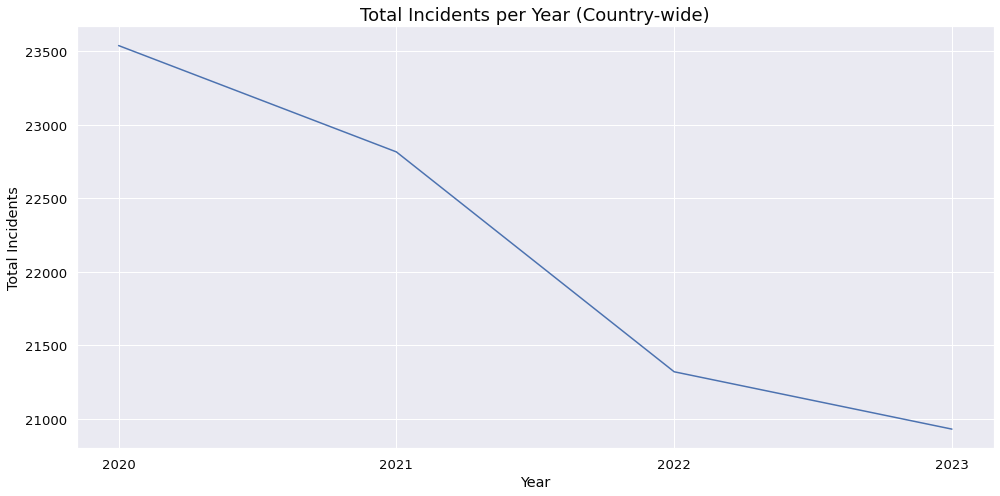

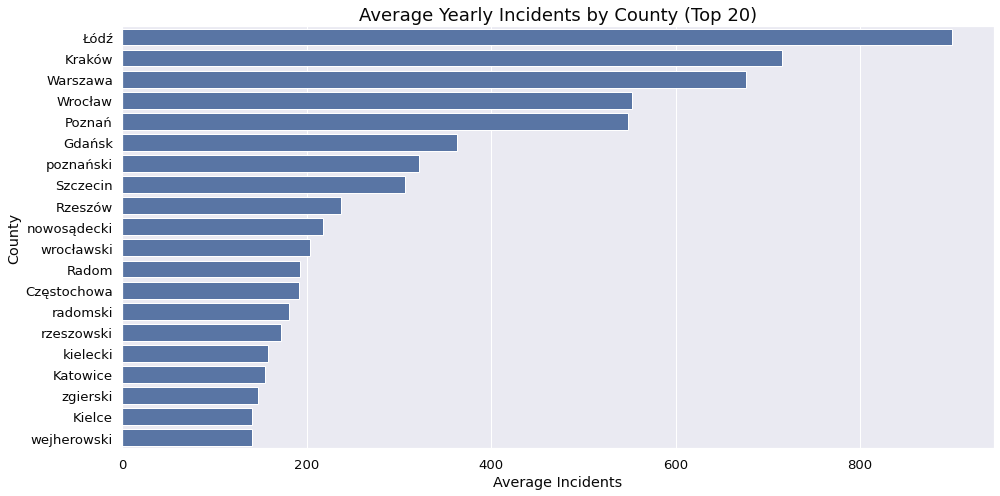

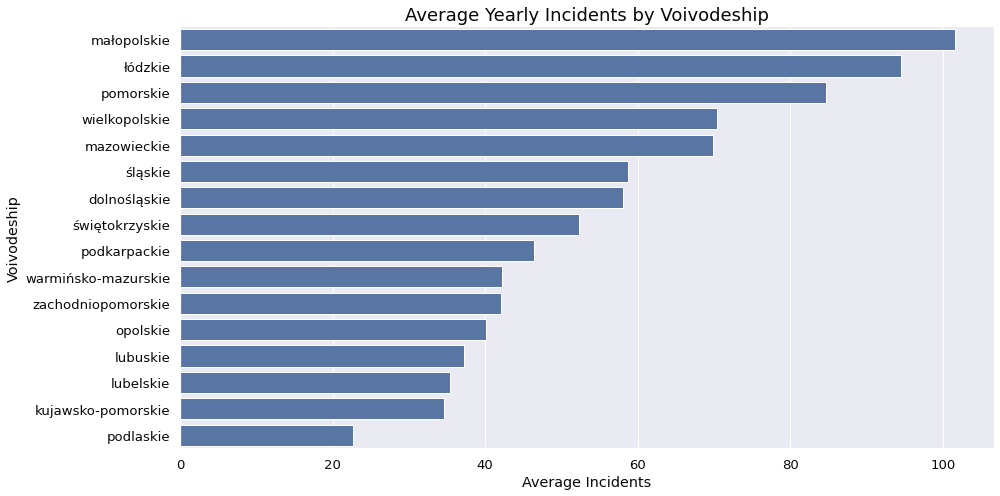

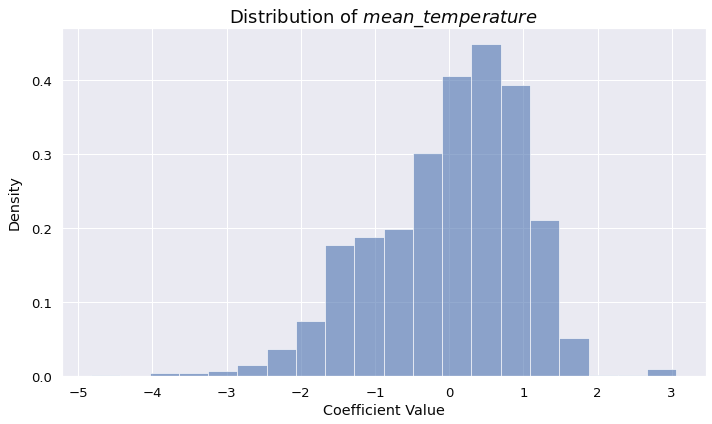

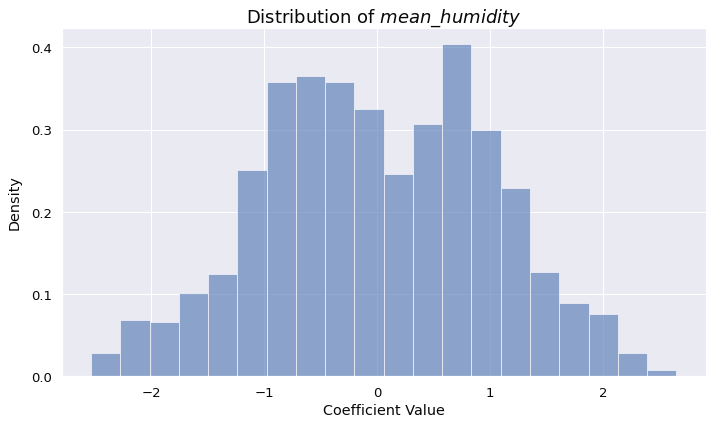

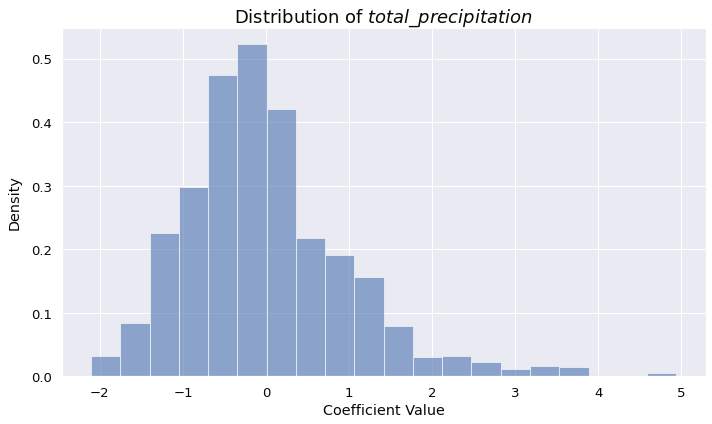

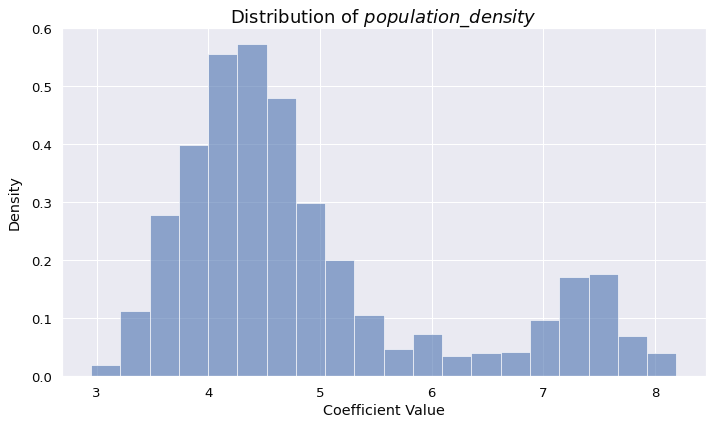

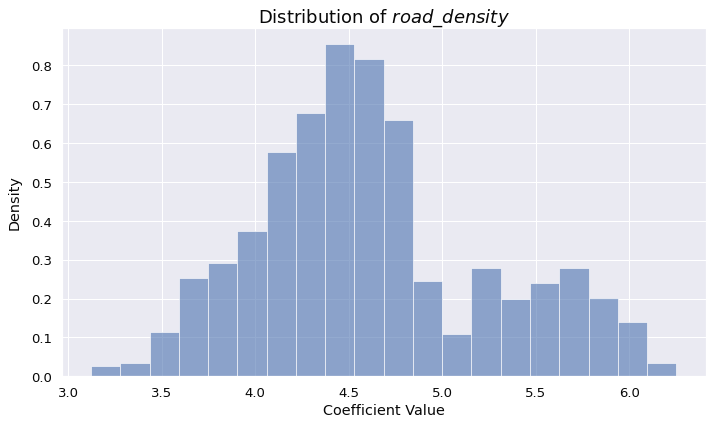

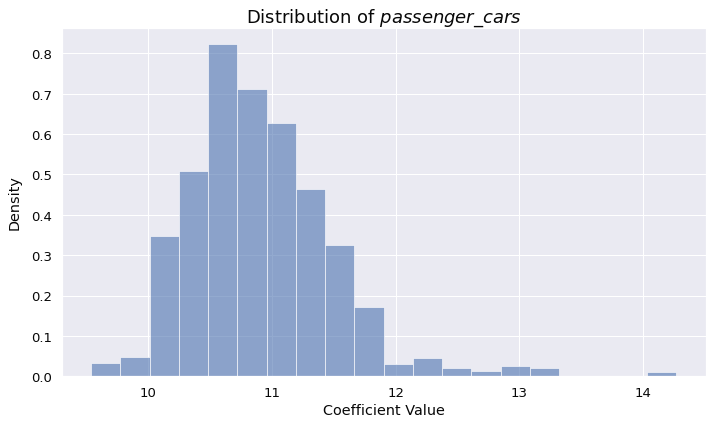

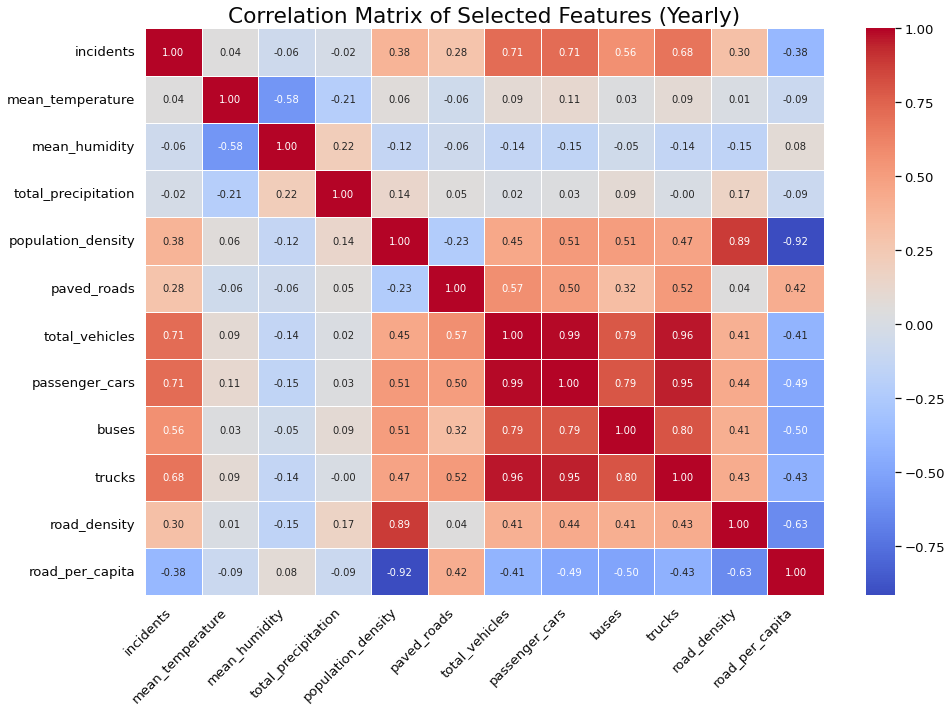

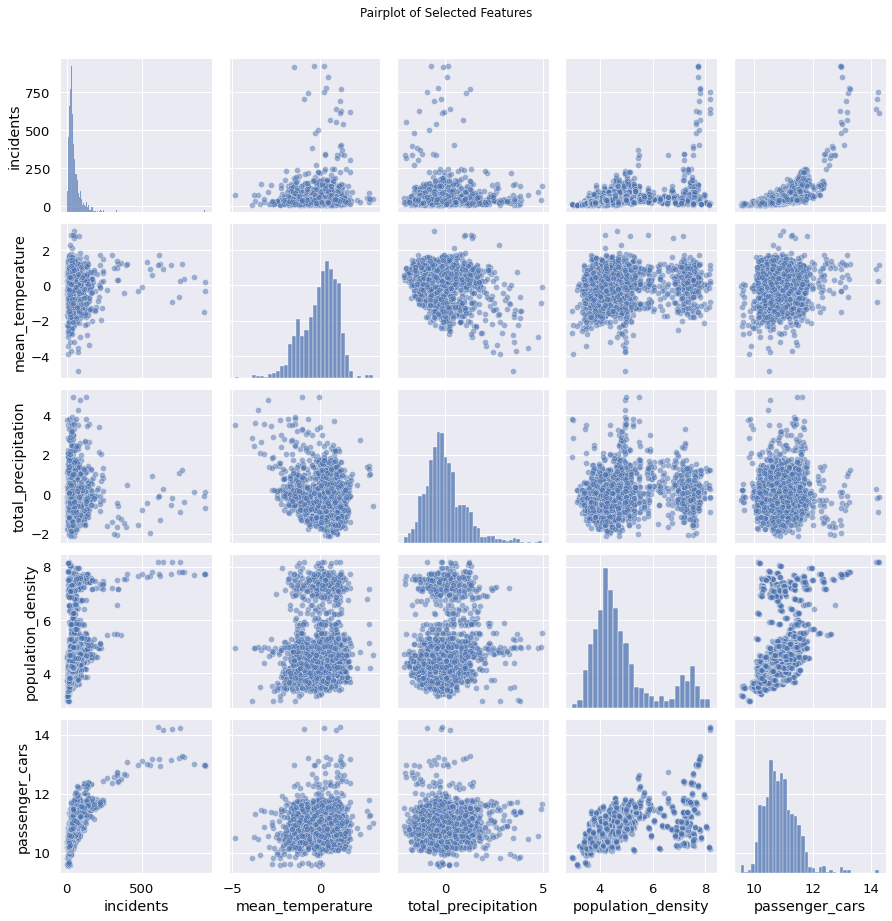

In [8]:
# Explore Yearly Data
# Create visualizations showing the yearly incident trends, spatial patterns, and relationships 
# between incidents and key predictors (weather factors and socioeconomic variables)
from matplotlib.dates import MonthLocator, DateFormatter
from matplotlib.ticker import FormatStrFormatter, MultipleLocator

# Time series plot of incidents by year across all counties
plt.figure(figsize=(14, 7))
yearly_totals = df_yearly.groupby('year')['incidents'].sum().reset_index()
yearly_totals['year'] = yearly_totals['year'].astype(str)  # Convert year to string for better x-axis formatting
sns.lineplot(x='year', y='incidents', data=yearly_totals)
plt.title('Total Incidents per Year (Country-wide)', fontsize=18)
plt.xlabel('Year')
plt.ylabel('Total Incidents')
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%d'))  # Format as integers
plt.grid(True)
plt.tight_layout()
plt.show()

# Distribution of incidents by county
plt.figure(figsize=(14, 7))
county_totals = df_yearly.groupby('county')['incidents'].mean().sort_values(ascending=False).reset_index()
top_counties = county_totals.head(20)  # Top 20 counties
sns.barplot(x='incidents', y='county', data=top_counties)
plt.title('Average Yearly Incidents by County (Top 20)', fontsize=18)
plt.xlabel('Average Incidents')
plt.ylabel('County')
plt.tight_layout()
plt.show()

# Distribution of incidents by voivodeship
plt.figure(figsize=(14, 7))
voivodeship_totals = df_yearly.groupby('voivodeship')['incidents'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='incidents', y='voivodeship', data=voivodeship_totals)
plt.title('Average Yearly Incidents by Voivodeship', fontsize=18)
plt.xlabel('Average Incidents')
plt.ylabel('Voivodeship')
plt.tight_layout()
plt.show()

# # Scatterplot: Incidents vs. Mean Temperature
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x='mean_temperature', y='incidents', data=df_yearly, alpha=0.6, hue='year')
# plt.title('Incidents vs. Mean Temperature (Yearly)')
# plt.xlabel('Normalized Mean Temperature')
# plt.ylabel('Number of Incidents')
# plt.legend(title='Year')
# plt.show()

# # Scatterplot: Incidents vs. Population Density
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x='population_density', y='incidents', data=df_yearly, alpha=0.6, hue='year')
# plt.title('Incidents vs. Population Density (Yearly)')
# plt.xlabel('Log Population Density')
# plt.ylabel('Number of Incidents')
# plt.legend(title='Year')
# plt.show()

# # Scatterplot: Incidents vs. Passenger Cars
# plt.figure(figsize=(10, 6))
# sns.scatterplot(x='passenger_cars', y='incidents', data=df_yearly, alpha=0.6, hue='year')
# plt.title('Incidents vs. Passenger Cars (Yearly)')
# plt.xlabel('Log Passenger Cars')
# plt.ylabel('Number of Incidents')
# plt.legend(title='Year')
# plt.show()


predictors=  ['mean_temperature', 'mean_humidity', 'total_precipitation', 'population_density', 'road_density', 'passenger_cars']
for i, predictor in enumerate(predictors):
    plt.figure(figsize=(10, 6))
    plt.hist(df_yearly[predictor], bins=20, alpha=0.6, density=True)
    plt.title(f"Distribution of $\mathit{{{predictor.replace('_', '\_')}}}$", fontsize=18)
    plt.xlabel('Coefficient Value')
    plt.ylabel('Density', labelpad=10)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # Format to 1 decimal place
    plt.gca().yaxis.set_major_locator(MultipleLocator(0.1))  # Set minimum tick spacing to 0.5
    plt.tight_layout()
    plt.show()
 
# Correlation Analysis
plt.figure(figsize=(14, 10))
correlation_cols = ['incidents', 'mean_temperature', 'mean_humidity', 'total_precipitation', 
                   'population_density', 'paved_roads', 'total_vehicles', 'passenger_cars',
                   'buses', 'trucks', 'road_density', 'road_per_capita']
correlation_matrix = df_yearly[correlation_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Selected Features (Yearly)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# # Boxplot of incidents by year
# plt.figure(figsize=(12, 6))
# sns.boxplot(x='year', y='incidents', data=df_yearly)
# plt.title('Distribution of Incidents by Year')
# plt.xlabel('Year')
# plt.ylabel('Incidents')
# plt.yscale('log')
# plt.grid(True, axis='y')
# plt.tight_layout()
# plt.show()

# Pairplot of selected features
sns.pairplot(df_yearly[['incidents', 'mean_temperature', 'total_precipitation', 
                        'population_density', 'passenger_cars']], 
             plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot of Selected Features', y=1.02)
plt.tight_layout()
plt.show()

# Model 1: Socioeconomic Factors Only
Define the first model using only socioeconomic factors (population_density, road_density, passenger_cars) as predictors. Prepare the data structure for Stan with appropriate priors based on domain knowledge.

In [9]:
# Model 1: Socioeconomic Factors Only
from matplotlib.ticker import FormatStrFormatter, MultipleLocator

# Prepare the data structure for Stan
predictors_socio = ['population_density', 'passenger_cars', 'road_density']
X_socio = df_yearly[predictors_socio].values

# Define Stan data
stan_data_socio = {
    'N': len(df_yearly),
    'K': len(predictors_socio),
    'X': X_socio,
    'y': df_yearly['incidents'].values,
    'alpha_mean': 2.0,        # Prior for intercept, exp(3) ≈ 20 weekly incidents
    'alpha_sd': 0.5,          # Reasonable variation for yearly data
    'beta_sd': 0.15,           # Prior for coefficients
    'max_log_lambda': 6.8     # log(400) ≈ 6.0, caps lambda at ~400 yearly incidents
}

# Display the prepared data dimensions
print(f"Number of observations (N): {stan_data_socio['N']}")
print(f"Number of predictors (K): {stan_data_socio['K']}")

Number of observations (N): 1520
Number of predictors (K): 3


# Prior Analysis for Model 1
Sample from prior distributions for the socioeconomic-only model. Create separate figures for each coefficient and intercept prior distribution, following the same approach as in the weekly analysis.

In [10]:
# Prior Analysis for Model 1

# Compile the prior model
prior_model_socio = CmdStanModel(stan_file="models/socioeconomic_prior.stan")

# Sample from prior
prior_fit_socio = prior_model_socio.sample(
    data=stan_data_socio,
    iter_sampling=2000,
    iter_warmup=500,
    chains=4,
    fixed_param=True,
    seed=42,
    output_dir='./models_outputs'
)

# Extract prior samples
alpha_prior_socio = prior_fit_socio.stan_variable("alpha")
beta_prior_socio = prior_fit_socio.stan_variable("beta")
y_prior_socio = prior_fit_socio.stan_variable("y_prior")

INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▋         | 00:00 Iteration:    1 / 2000 [  0%]  (Sampling)


chain 1 |█▍        | 00:00 Iteration:  200 / 2000 [ 10%]  (Sampling)


chain 1 |██▏       | 00:00 Iteration:  400 / 2000 [ 20%]  (Sampling)



chain 1 |██▉       | 00:00 Iteration:  600 / 2000 [ 30%]  (Sampling)




chain 1 |███▋      | 00:00 Iteration:  800 / 2000 [ 40%]  (Sampling)



chain 1 |████▍     | 00:00 Iteration: 1000 / 2000 [ 50%]  (Sampling)


chain 1 |█████▏    | 00:01 Iteration: 1200 / 2000 [ 60%]  (Sampling)

chain 1 |██████████| 00:01 Sampling completed                       
chain 2 |██████████| 00:01 Sampling completed                       

chain 3 |██████████| 00:01 Sampling completed


chain 4 |██████████| 00:01 Sampling completed


INFO:cmdstanpy:CmdStan done processing.


<>:29: SyntaxWarning: invalid escape sequence '\_'
<>:29: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_620/193995058.py:29: SyntaxWarning: invalid escape sequence '\_'
  plt.title(f'Prior Distribution of the $\\mathit{{{predictor.replace('_', '\_')}}}$ Coefficient ($\\beta_{{{i+1}}}$)', fontsize=18)


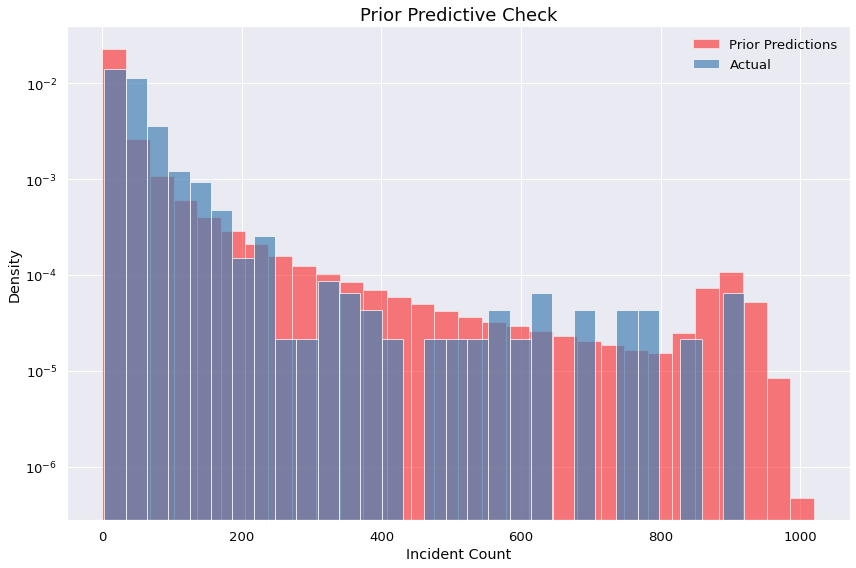

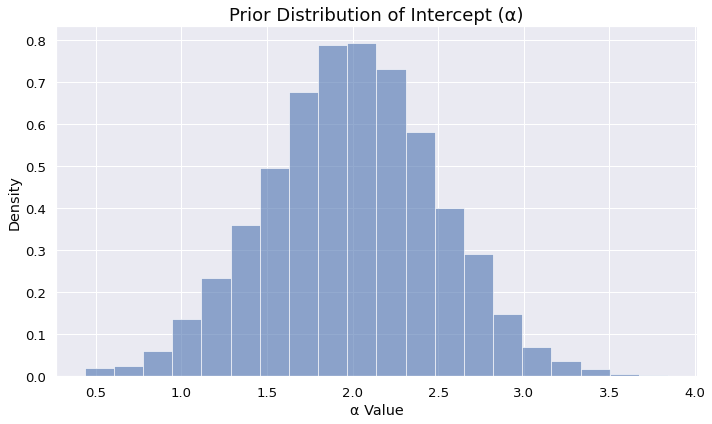

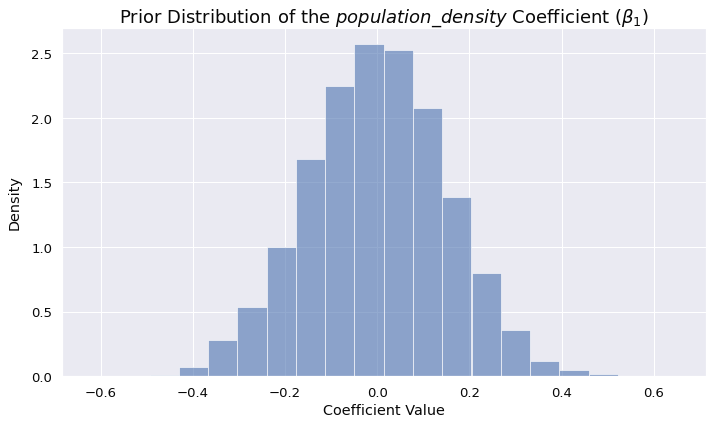

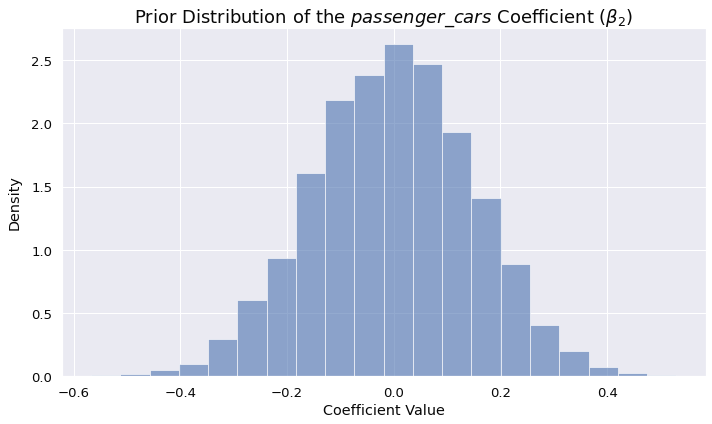

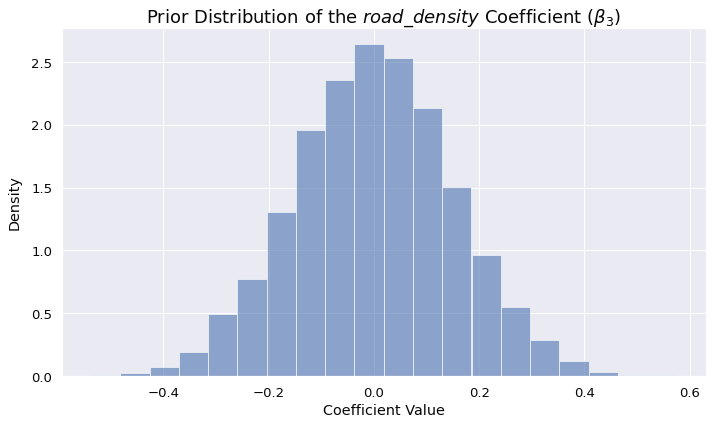

In [11]:

# Prior Predictive Check
plt.figure(figsize=(12, 8))
y_prior_flat_socio = y_prior_socio.flatten()
valid_indices_socio = ~np.isnan(y_prior_flat_socio)
plt.hist(y_prior_flat_socio[valid_indices_socio], bins=30, alpha=0.5, color='red', label='Prior Predictions', density=True)
plt.hist(df_yearly['incidents'], bins=30, alpha=0.7, color='steelblue', label='Actual', density=True)
plt.yscale('log')
plt.title('Prior Predictive Check', fontsize=18)
plt.xlabel('Incident Count')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# Prior distribution of intercept
plt.figure(figsize=(10, 6))
plt.hist(alpha_prior_socio, bins=20, alpha=0.6, density=True)
plt.title('Prior Distribution of Intercept (α)', fontsize=18)
plt.xlabel('α Value')
plt.ylabel('Density')
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # Format to 1 decimal place
plt.tight_layout()
plt.show()

# Prior distribution of socioeconomic coefficients
for i, predictor in enumerate(predictors_socio):
    plt.figure(figsize=(10, 6))
    plt.hist(beta_prior_socio[:, i], bins=20, alpha=0.6, density=True)
    plt.title(f'Prior Distribution of the $\\mathit{{{predictor.replace('_', '\_')}}}$ Coefficient ($\\beta_{{{i+1}}}$)', fontsize=18)
    plt.xlabel('Coefficient Value')
    plt.ylabel('Density', labelpad=10)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # Format to 1 decimal place
    plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))  # Set minimum tick spacing to 0.5
    plt.tight_layout()
    plt.show()

# Posterior Analysis for Model 1
Fit the socioeconomic model using Stan and analyze posterior distributions. Create trace plots and posterior density plots for each coefficient/intercept, providing clear statistical interpretations.

In [12]:
# Posterior Analysis for Model 1

# Compile the posterior model
posterior_model_socio = CmdStanModel(stan_file="models/socioeconomic_posterior.stan")

# Sample from the posterior
posterior_fit_socio = posterior_model_socio.sample(
    data=stan_data_socio,
    iter_sampling=2000,
    iter_warmup=500,
    chains=4,
    seed=42,
    output_dir='./models_outputs'
)

# Extract posterior samples
alpha_post_socio = posterior_fit_socio.stan_variable("alpha")
beta_post_socio = posterior_fit_socio.stan_variable("beta")
y_rep_socio = posterior_fit_socio.stan_variable("y_rep")

INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |▋         | 00:00 Iteration:    1 / 2500 [  0%]  (Warmup)


chain 1 |█▍        | 00:00 Iteration:  200 / 2500 [  8%]  (Warmup)


chain 1 |██▏       | 00:02 Iteration:  400 / 2500 [ 16%]  (Warmup)


chain 1 |██▉       | 00:04 Iteration:  501 / 2500 [ 20%]  (Sampling)




chain 1 |███▎      | 00:05 Iteration:  600 / 2500 [ 24%]  (Sampling)


chain 1 |███▋      | 00:07 Iteration:  700 / 2500 [ 28%]  (Sampling)





chain 1 |████      | 00:08 Iteration:  800 / 2500 [ 32%]  (Sampling)



chain 1 |████▍     | 00:10 Iteration:  900 / 2500 [ 36%]  (Sampling)




chain 1 |████▊     | 00:12 Iteration: 1000 / 2500 [ 40%]  (Sampling)



chain 1 |█████▏    | 00:14 Iteration: 1100 / 2500 [ 44%]  (Sampling)




chain 1 |█████▌    | 00:15 Iteration: 1200 / 2500 [ 48%]  (Sampling)



chain 1 |█████▉    | 00:17 Iteration: 1300 / 2500 [ 52%]  (Sampling)




chain 1 |██


INFO:cmdstanpy:CmdStan done processing.


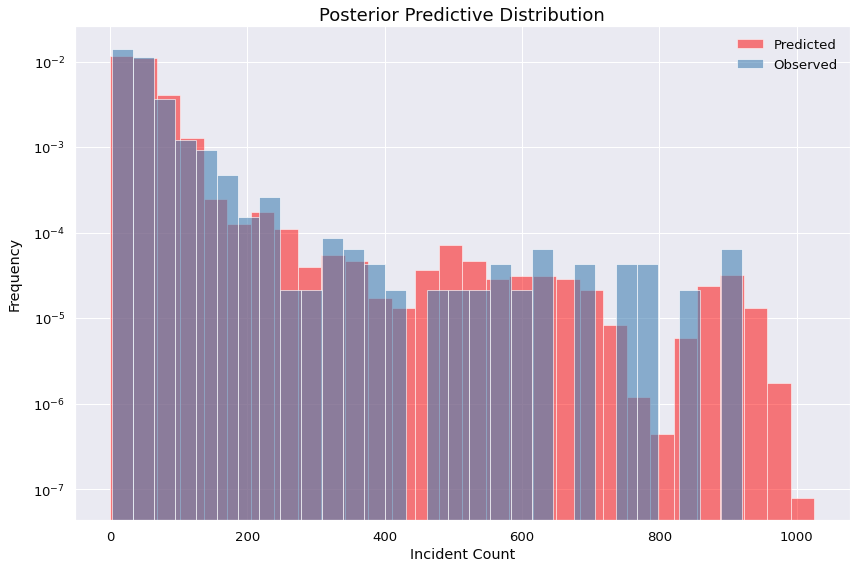

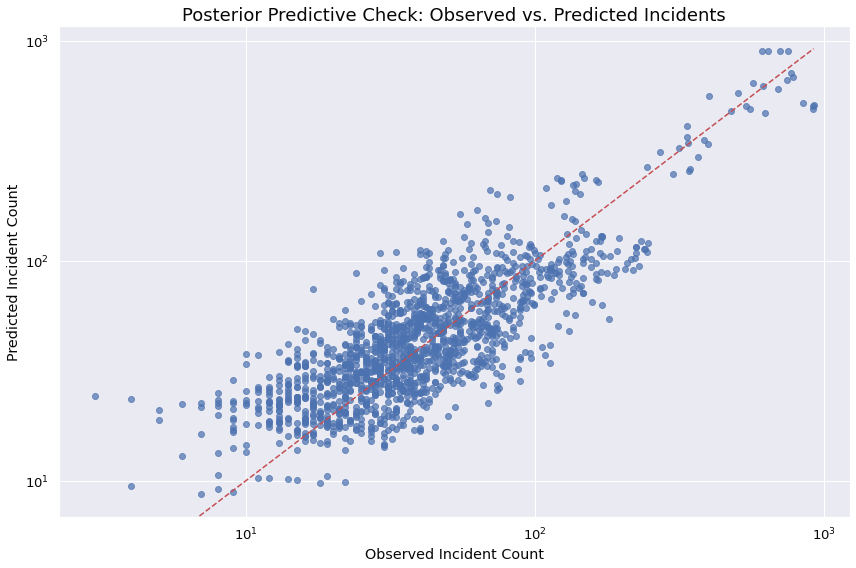

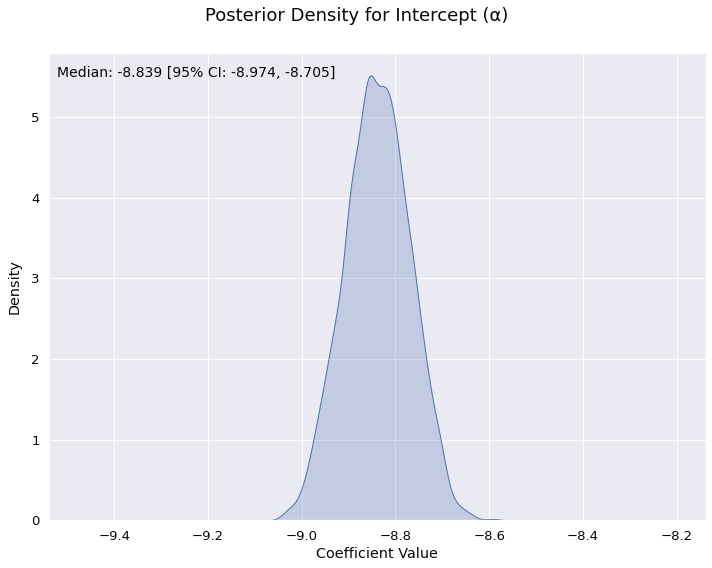

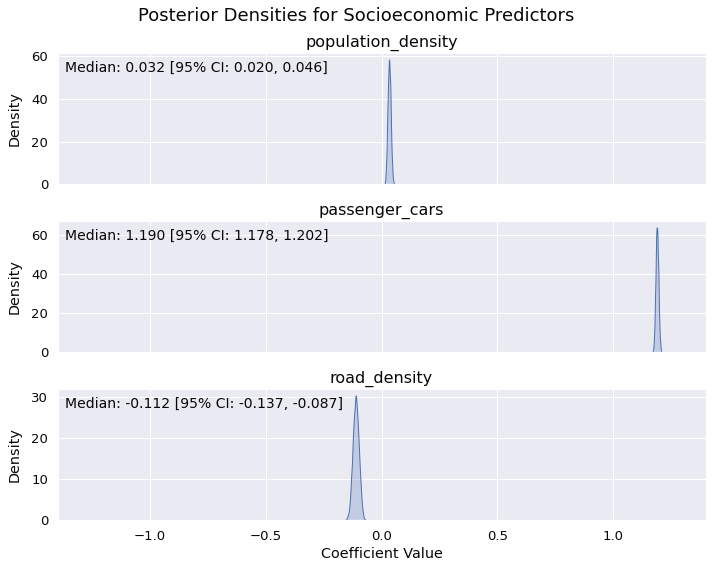

In [13]:
# Posterior Predictive Check
plt.figure(figsize=(12, 8))
plt.hist(y_rep_socio.flatten(), bins=30, alpha=0.5, color='red', label='Predicted', density=True)
plt.hist(df_yearly['incidents'], bins=30, alpha=0.6, color='steelblue', label='Observed', density=True)
plt.title('Posterior Predictive Distribution', fontsize=18)
plt.xlabel('Incident Count')
plt.ylabel('Frequency', labelpad=12)
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
if len(y_rep_socio.shape) > 1:
    y_rep_socio = np.mean(y_rep_socio, axis=0)
plt.scatter(df_yearly['incidents'], y_rep_socio, alpha=0.7)
plt.plot([0, df_yearly['incidents'].max()], [0, df_yearly['incidents'].max()], 'r--')
plt.xlabel('Observed Incident Count')
plt.ylabel('Predicted Incident Count')
plt.xscale('log')
plt.yscale('log')

plt.title('Posterior Predictive Check: Observed vs. Predicted Incidents', fontsize=18)
plt.tight_layout()
plt.show()

# Alpha density - same figsize as the stacked beta plots
fig_alpha, ax_alpha = plt.subplots(figsize=(10, 8))
fig_alpha.suptitle('Posterior Density for Intercept (α)', fontsize=18)

sns.kdeplot(alpha_post_socio, fill=True, ax=ax_alpha)
ax_alpha.set_title('')
ax_alpha.set_xlabel('Coefficient Value')
ax_alpha.set_ylabel('Density', labelpad=10)

# Add median and 95% CI annotation for alpha
median_alpha = np.median(alpha_post_socio)
ci_lower_alpha = np.percentile(alpha_post_socio, 2.5)
ci_upper_alpha = np.percentile(alpha_post_socio, 97.5)
ax_alpha.annotate(f'Median: {median_alpha:.3f} [95% CI: {ci_lower_alpha:.3f}, {ci_upper_alpha:.3f}]', 
                 xy=(0.012, 0.95), xycoords='axes fraction', fontsize=14)

plt.xlim(median_alpha - 0.7, median_alpha + 0.7) 
plt.tight_layout()
fig_alpha.subplots_adjust(top=0.9)  # Make room for the suptitle
plt.show()

# Beta densities - create two stacked plots (first 3 and last 3)
# First figure - first three predictors
fig1, axes1 = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig1.suptitle('Posterior Densities for Socioeconomic Predictors', fontsize=18)

for i in range(3):
    predictor = predictors_socio[i]
    sns.kdeplot(beta_post_socio[:, i], fill=True, ax=axes1[i])
    axes1[i].set_title(f'{predictor}', fontsize=16)
    axes1[i].set_xlim(-1.4, 1.4)
    axes1[i].set_ylabel('Density', labelpad=10)
    
    # Add median and 95% CI annotation
    median = np.median(beta_post_socio[:, i])
    ci_lower = np.percentile(beta_post_socio[:, i], 2.5)
    ci_upper = np.percentile(beta_post_socio[:, i], 97.5)
    axes1[i].annotate(f'Median: {median:.3f} [95% CI: {ci_lower:.3f}, {ci_upper:.3f}]', 
                     xy=(0.012, 0.86), xycoords='axes fraction' , fontsize=14)

# Only set xlabel for the bottom plot
axes1[-1].set_xlabel('Coefficient Value')
plt.tight_layout()
fig1.subplots_adjust(top=0.9)  # Make room for the suptitle
plt.show()

# Model 2: Socioeconomic + Weather Factors
Define the comprehensive model using both socioeconomic and weather predictors. Prepare data for Stan with appropriate priors, similar to the first model but with additional weather variables.

In [14]:
# Model 2: Socioeconomic + Weather Factors

# Prepare the data structure for Stan
predictors_socio_weather = predictors_socio + ['mean_temperature', 'mean_humidity', 'total_precipitation']
X_socio_weather = df_yearly[predictors_socio_weather].values

# Define Stan data
stan_data_socio_weather = {
    'N': len(df_yearly),
    'K': len(predictors_socio_weather),
    'X': X_socio_weather,
    'y': df_yearly['incidents'].values,
    'alpha_mean': 2.0,        # Prior for intercept, exp(3) ≈ 20 weekly incidents
    'alpha_sd': 0.5,          # Reasonable variation for yearly data
    'beta_sd': 0.15,           # Prior for coefficients
    'max_log_lambda': 6.8     # log(400) ≈ 6.0, caps lambda at ~400 yearly incidents
}

# Display the prepared data dimensions
print(f"Number of observations (N): {stan_data_socio_weather['N']}")
print(f"Number of predictors (K): {stan_data_socio_weather['K']}")

Number of observations (N): 1520
Number of predictors (K): 6


# Prior Analysis for Model 2
Sample from prior distributions for the comprehensive model. Create separate figures for each coefficient and intercept prior distribution, maintaining the same visualization style as Model 1.

In [15]:
# Prior Analysis for Model 2

# Compile the prior model
prior_model_socio_weather = CmdStanModel(stan_file="models/socioeconomic_prior.stan")

# Sample from prior
prior_fit_socio_weather = prior_model_socio_weather.sample(
    data=stan_data_socio_weather,
    iter_sampling=2000,
    iter_warmup=500,
    chains=4,
    fixed_param=True,
    seed=42,
    output_dir='./models_outputs'
)

# Extract prior samples
alpha_prior_socio_weather = prior_fit_socio_weather.stan_variable("alpha")
beta_prior_socio_weather = prior_fit_socio_weather.stan_variable("beta")
y_prior_socio_weather = prior_fit_socio_weather.stan_variable("y_prior")

INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status





chain 1 |█         | 00:00 Iteration:  100 / 2000 [  5%]  (Sampling)


chain 1 |█▊        | 00:00 Iteration:  300 / 2000 [ 15%]  (Sampling)


chain 1 |██▌       | 00:00 Iteration:  500 / 2000 [ 25%]  (Sampling)



chain 1 |███▎      | 00:00 Iteration:  700 / 2000 [ 35%]  (Sampling)




chain 1 |████      | 00:00 Iteration:  900 / 2000 [ 45%]  (Sampling)


chain 1 |████▊     | 00:01 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████████| 00:01 Sampling completed                       
chain 2 |██████████| 00:01 Sampling completed                       

chain 3 |██████████| 00:01 Sampling completed


chain 4 |██████████| 00:01 Sampling completed


INFO:cmdstanpy:CmdStan done processing.


<>:29: SyntaxWarning: invalid escape sequence '\_'
<>:29: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_620/1070854741.py:29: SyntaxWarning: invalid escape sequence '\_'
  plt.title(f'Prior Distribution of the $\\mathit{{{predictor.replace('_', '\_')}}}$ Coefficient ($\\beta_{{{i+1}}}$)', fontsize=18)


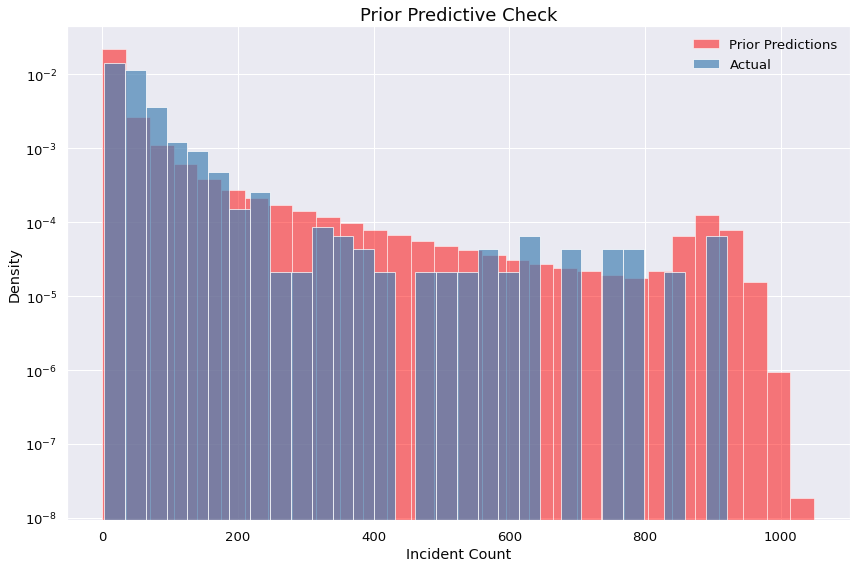

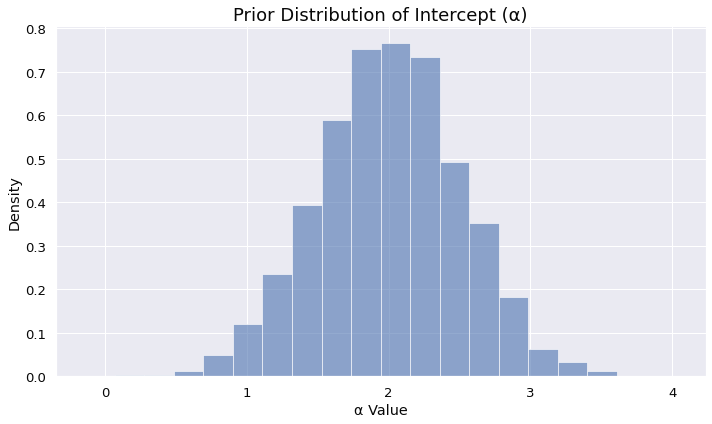

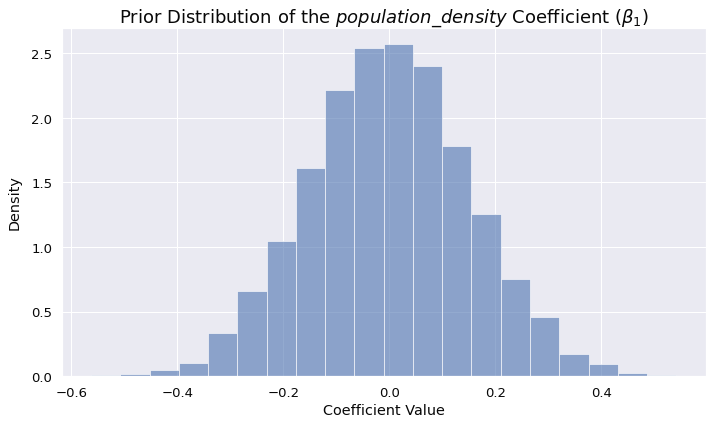

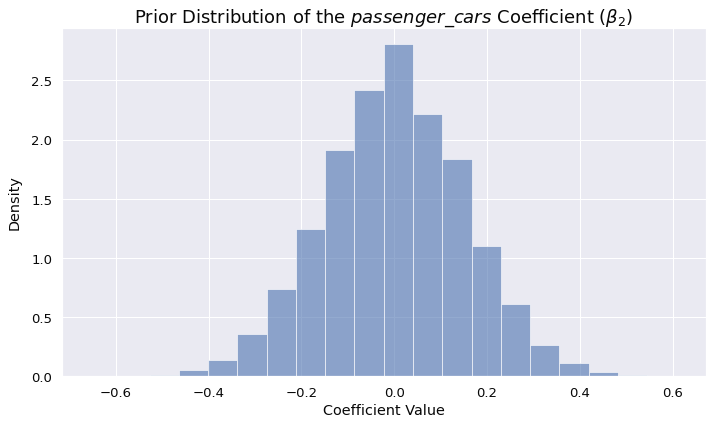

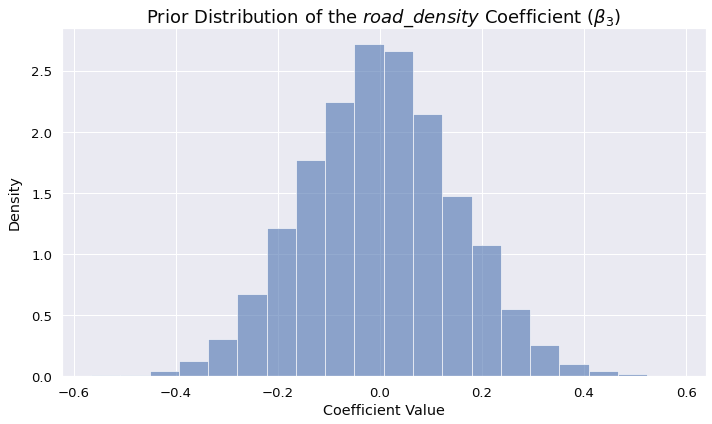

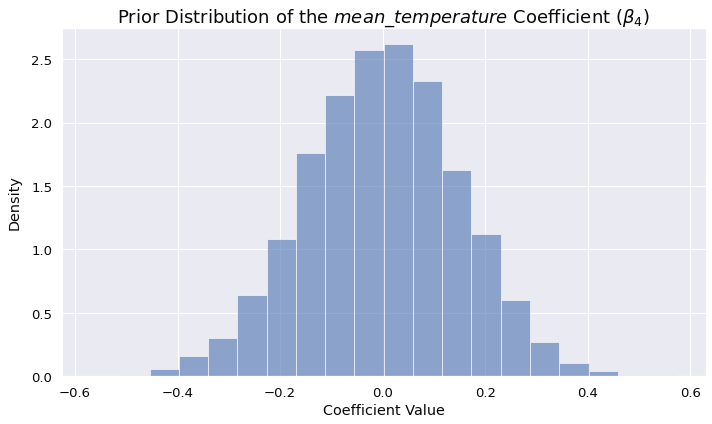

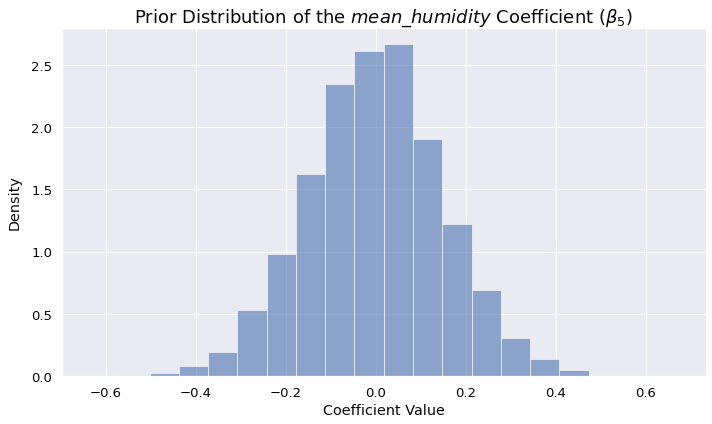

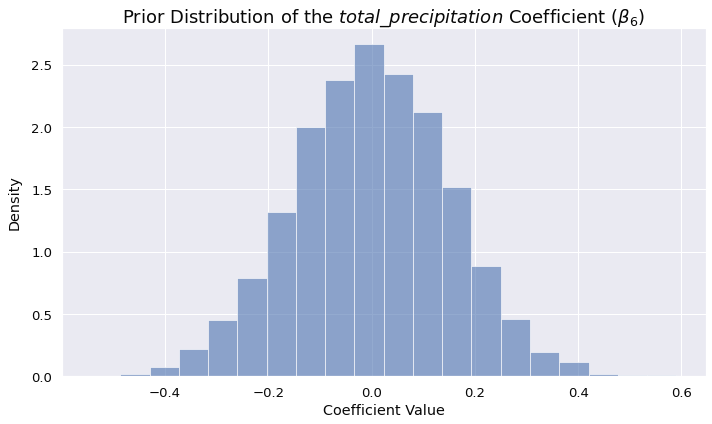

In [16]:

# Prior Predictive Check
plt.figure(figsize=(12, 8))
y_prior_flat_socio_weather = y_prior_socio_weather.flatten()
valid_indices_socio_weather = ~np.isnan(y_prior_flat_socio_weather)
plt.hist(y_prior_flat_socio_weather[valid_indices_socio_weather], bins=30, alpha=0.5, color='red', label='Prior Predictions', density=True)
plt.hist(df_yearly['incidents'], bins=30, alpha=0.7, color='steelblue', label='Actual', density=True)
plt.yscale('log')
plt.title('Prior Predictive Check', fontsize=18)
plt.xlabel('Incident Count')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

# Prior distribution of intercept
plt.figure(figsize=(10, 6))
plt.hist(alpha_prior_socio_weather, bins=20, alpha=0.6, density=True)
plt.title('Prior Distribution of Intercept (α)', fontsize=18)
plt.xlabel('α Value')
plt.ylabel('Density')
plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # Format to 1 decimal place
plt.tight_layout()
plt.show()

# Prior distribution of socioeconomic + weather coefficients
for i, predictor in enumerate(predictors_socio_weather):
    plt.figure(figsize=(10, 6))
    plt.hist(beta_prior_socio_weather[:, i], bins=20, alpha=0.6, density=True)
    plt.title(f'Prior Distribution of the $\\mathit{{{predictor.replace('_', '\_')}}}$ Coefficient ($\\beta_{{{i+1}}}$)', fontsize=18)
    plt.xlabel('Coefficient Value')
    plt.ylabel('Density', labelpad=10)
    plt.gca().yaxis.set_major_formatter(FormatStrFormatter('%.1f'))  # Format to 1 decimal place
    plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))  # Set minimum tick spacing to 0.5
    plt.tight_layout()
    plt.show()

# Posterior Analysis for Model 2
Fit the comprehensive model using Stan and analyze posterior distributions. Generate visualizations matching those in Model 1 to facilitate direct comparison between models.

In [17]:
# Posterior Analysis for Model 2

# Compile the posterior model
posterior_model_socio_weather = CmdStanModel(stan_file="models/socioeconomic_posterior.stan")

# Sample from the posterior
posterior_fit_socio_weather = posterior_model_socio_weather.sample(
    data=stan_data_socio_weather,
    iter_sampling=2000,
    iter_warmup=500,
    chains=4,
    seed=42,
    output_dir='./models_outputs'
)

# Extract posterior samples
alpha_post_socio_weather = posterior_fit_socio_weather.stan_variable("alpha")
beta_post_socio_weather = posterior_fit_socio_weather.stan_variable("beta")
y_rep_socio_weather = posterior_fit_socio_weather.stan_variable("y_rep")

INFO:cmdstanpy:found newer exe file, not recompiling
INFO:cmdstanpy:CmdStan start processing
chain 1 |          | 00:00 Status


chain 1 |█         | 00:00 Iteration:  100 / 2500 [  4%]  (Warmup)





chain 1 |█▊        | 00:04 Iteration:  300 / 2500 [ 12%]  (Warmup)


chain 1 |██▏       | 00:08 Iteration:  400 / 2500 [ 16%]  (Warmup)










chain 1 |██▉       | 00:14 Iteration:  501 / 2500 [ 20%]  (Sampling)














chain 1 |███▎      | 00:20 Iteration:  600 / 2500 [ 24%]  (Sampling)















chain 1 |███▋      | 00:26 Iteration:  700 / 2500 [ 28%]  (Sampling)














chain 1 |████      | 00:33 Iteration:  800 / 2500 [ 32%]  (Sampling)





chain 1 |██████████| 01:53 Sampling completed                       
chain 2 |██████████| 01:53 Sampling completed                       
chain 3 |██████████| 01:53 Sampling completed                       
chain 4 |██████████| 01:53 Sampling completed                       


INFO:cmdstanpy:CmdStan done processing.


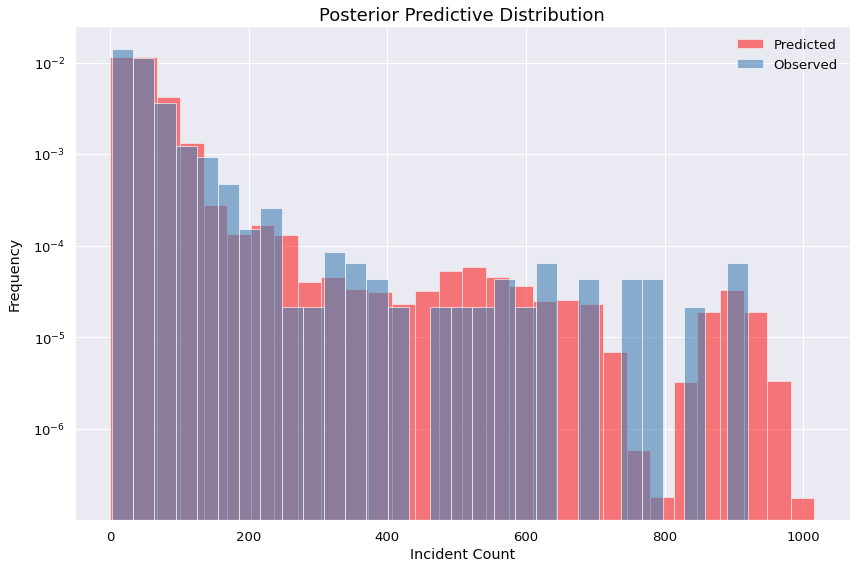

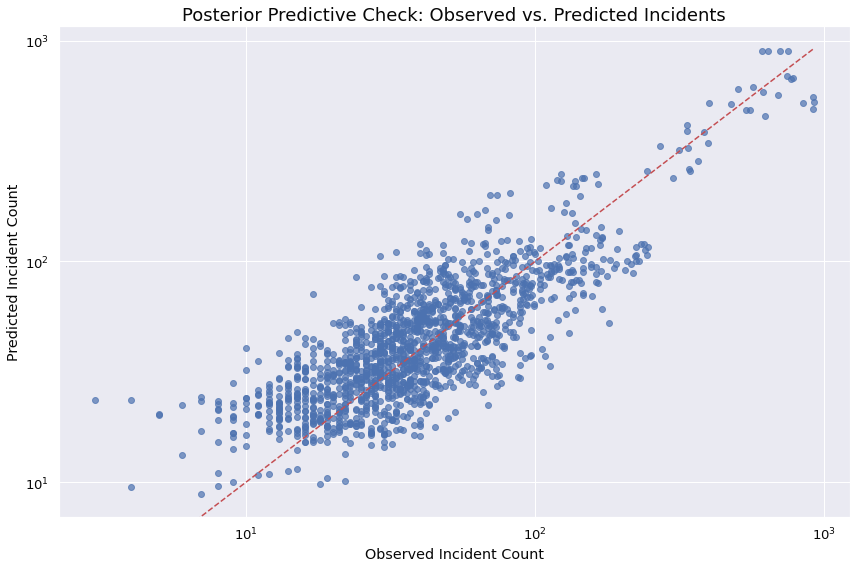

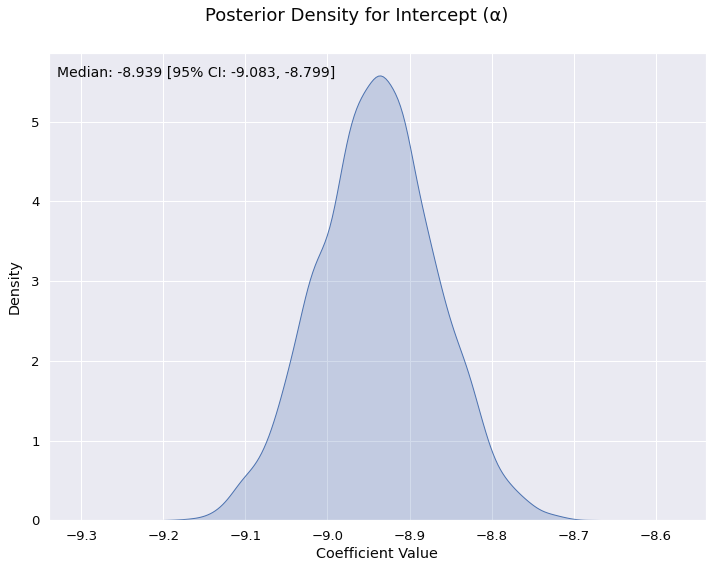

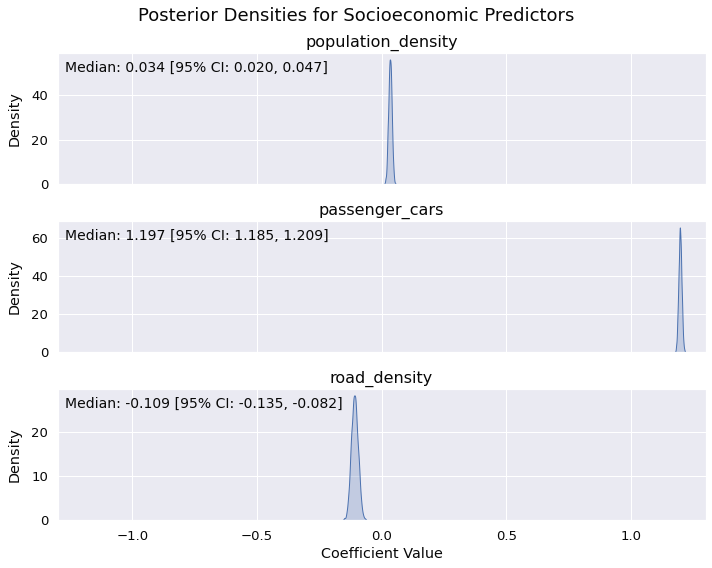

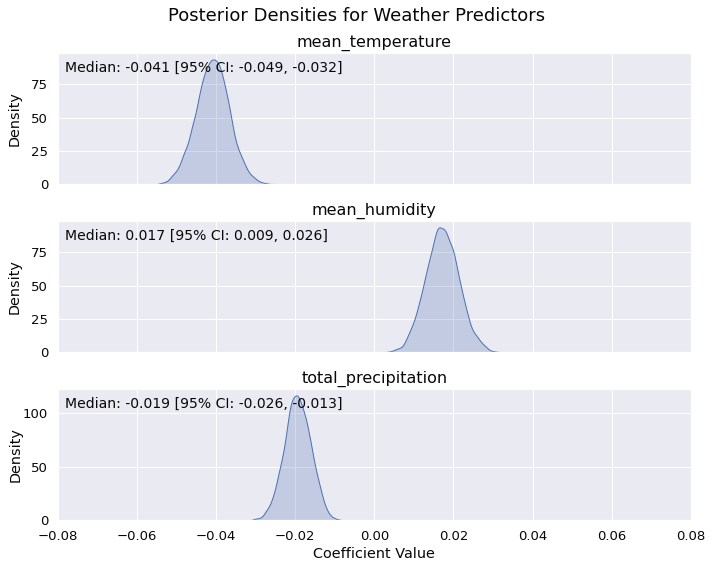

In [18]:

# Posterior Predictive Check
plt.figure(figsize=(12, 8))
plt.hist(y_rep_socio_weather.flatten(), bins=30, alpha=0.5, color='red', label='Predicted', density=True)
plt.hist(df_yearly['incidents'], bins=30, alpha=0.6, color='steelblue', label='Observed', density=True)
plt.title('Posterior Predictive Distribution', fontsize=18)
plt.xlabel('Incident Count')
plt.ylabel('Frequency', labelpad=12)
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
if len(y_rep_socio_weather.shape) > 1:
    y_rep_socio_weather = np.mean(y_rep_socio_weather, axis=0)
plt.scatter(df_yearly['incidents'], y_rep_socio_weather, alpha=0.7)
plt.plot([0, df_yearly['incidents'].max()], [0, df_yearly['incidents'].max()], 'r--')
plt.xlabel('Observed Incident Count')
plt.ylabel('Predicted Incident Count')
plt.xscale('log')
plt.yscale('log')
plt.title('Posterior Predictive Check: Observed vs. Predicted Incidents', fontsize=18)
plt.tight_layout()
plt.show()

# Alpha density - same figsize as the stacked beta plots
fig_alpha, ax_alpha = plt.subplots(figsize=(10, 8))
fig_alpha.suptitle('Posterior Density for Intercept (α)', fontsize=18)

sns.kdeplot(alpha_post_socio_weather, fill=True, ax=ax_alpha)
ax_alpha.set_title('')
ax_alpha.set_xlabel('Coefficient Value')
ax_alpha.set_ylabel('Density', labelpad=10)

# Add median and 95% CI annotation for alpha
median_alpha = np.median(alpha_post_socio_weather)
ci_lower_alpha = np.percentile(alpha_post_socio_weather, 2.5)
ci_upper_alpha = np.percentile(alpha_post_socio_weather, 97.5)
ax_alpha.annotate(f'Median: {median_alpha:.3f} [95% CI: {ci_lower_alpha:.3f}, {ci_upper_alpha:.3f}]', 
                 xy=(0.012, 0.95), xycoords='axes fraction', fontsize=14)

plt.xlim(median_alpha - 0.4, median_alpha + 0.4) 
plt.tight_layout()
fig_alpha.subplots_adjust(top=0.9)  # Make room for the suptitle
plt.show()

# Beta densities - create two stacked plots (first 3 and last 3)
# First figure - first three predictors
fig1, axes1 = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig1.suptitle('Posterior Densities for Socioeconomic Predictors', fontsize=18)

for i in range(3):
    predictor = predictors_socio_weather[i]
    sns.kdeplot(beta_post_socio_weather[:, i], fill=True, ax=axes1[i])
    axes1[i].set_title(f'{predictor}', fontsize=16)
    axes1[i].set_xlim(-1.3, 1.3)
    axes1[i].set_ylabel('Density', labelpad=10)
    
    # Add median and 95% CI annotation
    median = np.median(beta_post_socio_weather[:, i])
    ci_lower = np.percentile(beta_post_socio_weather[:, i], 2.5)
    ci_upper = np.percentile(beta_post_socio_weather[:, i], 97.5)
    axes1[i].annotate(f'Median: {median:.3f} [95% CI: {ci_lower:.3f}, {ci_upper:.3f}]', 
                     xy=(0.012, 0.86), xycoords='axes fraction' , fontsize=14)

# Only set xlabel for the bottom plot
axes1[-1].set_xlabel('Coefficient Value')
plt.tight_layout()
fig1.subplots_adjust(top=0.9)  # Make room for the suptitle
plt.show()

# Second figure - last three predictors
fig2, axes2 = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
fig2.suptitle('Posterior Densities for Weather Predictors', fontsize=18)
for i in range(3):
    idx = i + 3
    predictor = predictors_socio_weather[idx]
    sns.kdeplot(beta_post_socio_weather[:, idx], fill=True, ax=axes2[i])
    axes2[i].set_title(f'{predictor}', fontsize=16)
    axes2[i].set_xlim(-0.08, 0.08)
    axes2[i].set_ylabel('Density', labelpad=10)
    
    # Add median and 95% CI annotation
    median = np.median(beta_post_socio_weather[:, idx])
    ci_lower = np.percentile(beta_post_socio_weather[:, idx], 2.5)
    ci_upper = np.percentile(beta_post_socio_weather[:, idx], 97.5)
    axes2[i].annotate(f'Median: {median:.3f} [95% CI: {ci_lower:.3f}, {ci_upper:.3f}]', 
                     xy=(0.012, 0.86), xycoords='axes fraction', fontsize=14)

axes2[i].set_ylabel('Density', labelpad=0)
axes2[-1].set_xlabel('Coefficient Value')

plt.tight_layout()
fig2.subplots_adjust(top=0.9)  # Make room for the suptitle
plt.show()

# Model Comparison
Compare the two models using appropriate metrics such as WAIC and LOO-CV. Create visualizations showing prediction accuracy and residuals for both models to determine which performs better at predicting county-level yearly incidents.

<>:25: SyntaxWarning: invalid escape sequence '\M'
<>:25: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipykernel_620/2340514784.py:25: SyntaxWarning: invalid escape sequence '\M'
  print("\Model Comparison using the PSIS-LOO criterion:")
/usr/local/lib/python3.12/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.12/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You sh

WAIC for Socioeconomic Factors Only Model: Computed from 8000 posterior samples and 1520 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -12874.76   448.08
p_waic       94.67        -

There has been a warning during the calculation. Please check the results.
WAIC for Socioeconomic + Weather Factors Model: Computed from 8000 posterior samples and 1520 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -12789.84   436.54
p_waic      153.76        -

There has been a warning during the calculation. Please check the results.

LOO-CV for Socioeconomic Factors Only Model: Computed from 8000 posterior samples and 1520 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -12872.12   447.29
p_loo       92.02        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1512   99.5%
   (0.70, 1]   (bad) 

/usr/local/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


\Model Comparison using the PSIS-LOO criterion:
         rank      elpd_loo       p_loo  elpd_diff    weight          se  \
Model 2     0 -12788.501228  152.423024   0.000000  0.543503  436.221811   
Model 1     1 -12872.115227   92.016233  83.613998  0.456497  447.287447   

              dse  warning scale  
Model 2   0.00000     True   log  
Model 1  67.56509     True   log  


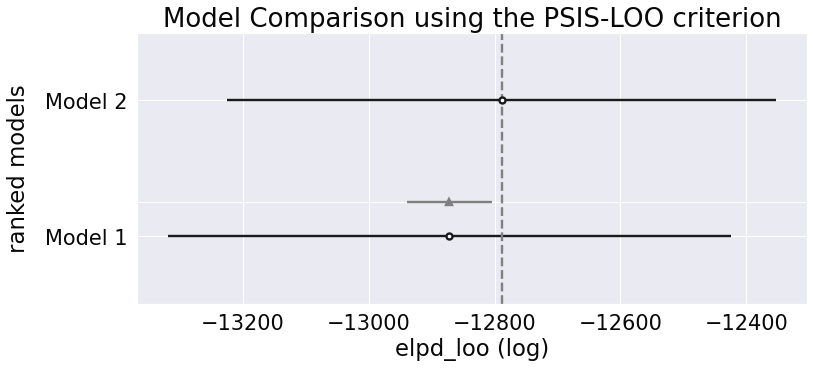

Model Comparison Summary:
         rank      elpd_loo       p_loo  elpd_diff    weight          se  \
Model 2     0 -12788.501228  152.423024   0.000000  0.543503  436.221811   
Model 1     1 -12872.115227   92.016233  83.613998  0.456497  447.287447   

              dse  warning scale  
Model 2   0.00000     True   log  
Model 1  67.56509     True   log  


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Model 2,0,-12788.501228,152.423024,0.000000,0.543503,436.221811,0.00000,True,log
Model 1,1,-12872.115227,92.016233,83.613998,0.456497,447.287447,67.56509,True,log


In [19]:
# Model Comparison

# Calculate WAIC for each model
waic_socio = az.waic(posterior_fit_socio)
waic_socio_weather = az.waic(posterior_fit_socio_weather)

# Calculate LOO-CV for each model
loo_socio = az.loo(posterior_fit_socio)
loo_socio_weather = az.loo(posterior_fit_socio_weather)

# Print WAIC and LOO-CV results
print("WAIC for Socioeconomic Factors Only Model:", waic_socio)
print("WAIC for Socioeconomic + Weather Factors Model:", waic_socio_weather)

print("\nLOO-CV for Socioeconomic Factors Only Model:", loo_socio)
print("LOO-CV for Socioeconomic + Weather Factors Model:", loo_socio_weather)

# Compare models using WAIC and LOO-CV
model_comparison = az.compare({
    "Model 1": posterior_fit_socio,
    "Model 2": posterior_fit_socio_weather
}, ic='loo')

# Display model comparison
print("\Model Comparison using the PSIS-LOO criterion:")
print(model_comparison)

# Visualize model comparison
az.plot_compare(model_comparison, figsize=(12, 5), plot_ic_diff=True)
plt.title('Model Comparison using the PSIS-LOO criterion', fontdict={'fontsize': 26})
plt.ylabel('ranked models', labelpad=15)
plt.show()

# Visualize prediction accuracy and residuals for each model

# Add predictions to the dataset for each model
df_yearly['predicted_incidents_socio'] = y_rep_socio
df_yearly['predicted_incidents_socio_weather'] = y_rep_socio_weather

# Calculate residuals for each model
df_yearly['residuals_socio'] = df_yearly['incidents'] - df_yearly['predicted_incidents_socio']
df_yearly['residuals_socio_weather'] = df_yearly['incidents'] - df_yearly['predicted_incidents_socio_weather']

# Summary of model comparison
print("Model Comparison Summary:")
print(model_comparison)
model_comparison

In [20]:
model_comparison.to_dict() 

{'rank': {'Model 2': 0, 'Model 1': 1},
 'elpd_loo': {'Model 2': -12788.501228279201, 'Model 1': -12872.115226738135},
 'p_loo': {'Model 2': 152.4230240540055, 'Model 1': 92.01623313326309},
 'elpd_diff': {'Model 2': 0.0, 'Model 1': 83.61399845893429},
 'weight': {'Model 2': 0.5435026180227548, 'Model 1': 0.4564973819772452},
 'se': {'Model 2': 436.22181074362476, 'Model 1': 447.2874469064553},
 'dse': {'Model 2': 0.0, 'Model 1': 67.56508999542125},
 'warning': {'Model 2': True, 'Model 1': True},
 'scale': {'Model 2': 'log', 'Model 1': 'log'}}

# Results Interpretation
Interpret the results, discussing which factors are most important for predicting yearly traffic incidents at the county level. Analyze implications for traffic safety policy and infrastructure planning at the local government level.